In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import RobustScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

/home/bulent/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:34: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # fraction of entries where abs(y_true - y_pred) < epsilon
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [3]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -99.66000093484503 whereas concordance corr coef is 0.019481784354057573


In [4]:
with open('stations-6to31.pkl', 'rb') as f:
    datas = pickle.load(f)
    
x_train6_ = datas['x_train6']
y_train6 = datas['y_train6']
x_train_ = datas['x_train']
y_train = datas['y_train']
x_dev_ = datas['x_dev']
y_dev = datas['y_dev']
x_test_ = datas['x_test']
y_test = datas['y_test']

print(f'x_train shape: {x_train_.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [5]:
def scale_data(scaler, datas):
    # scaler is a scaling function from sklearn library
    # datas is a dictionary, containing 3 sets of x_data with keys - x_train, x_dev, x_test
    # fit on x_train and return the transformed sets of data
    
    x_train = scaler.fit_transform(datas['x_train'].astype(float))
    x_dev = scaler.transform(datas['x_dev'].astype(float))
    x_test = scaler.transform(datas['x_test'].astype(float))
    
    transformed = {'x_train': x_train, 'x_dev': x_dev, 'x_test': x_test}
    return transformed

data6_ = {'x_train': x_train6_, 'x_dev': x_dev_, 'x_test': x_test_}
data_ = {'x_train': x_train_, 'x_dev': x_dev_, 'x_test': x_test_}

data6 = scale_data(RobustScaler(), data6_)
data = scale_data(RobustScaler(), data_)

x_train6 = data6['x_train']
x_train = data['x_train']

x_dev6 = data6['x_dev']
x_dev = data['x_dev']

x_test6 = data6['x_test']
x_test = data['x_test']

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [6]:
data6_3v_ = {'x_train': x_train6_[:, [1, 3, 2]], 'x_dev': x_dev_[:, [1, 3, 2]], 'x_test': x_test_[:, [1, 3, 2]]}
data_3v_ = {'x_train': x_train_[:, [1, 3, 2]], 'x_dev': x_dev_[:, [1, 3, 2]], 'x_test': x_test_[:, [1, 3, 2]]}

data6_3v = scale_data(RobustScaler(), data6_3v_)
data_3v = scale_data(RobustScaler(), data_3v_)

x_train6_3v = data6_3v['x_train']
x_train_3v = data_3v['x_train']

x_dev6_3v = data6_3v['x_dev']
x_dev_3v = data_3v['x_dev']

x_test6_3v = data6_3v['x_test']
x_test_3v = data_3v['x_test']

y_train6_hh0 = y_train6 / x_train6_[:, 4]
y_train_hh0 = y_train / x_train_[:, 4]
y_dev_hh0 = y_dev / x_dev_[:, 4]
y_test_hh0 = y_test / x_test_[:, 4]

print(f'x_train shape: {x_train_3v.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_3v.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_3v.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_3v.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 3), y_train shape: (52416,)
x_train6 shape: (10654, 3), y_train6 shape: (10654,)
x_dev shape: (9011, 3), y_dev shape: (9011,)
x_test shape: (16899, 3), y_test shape: (16899,)


In [7]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test6 = []
metrics_train6 = []
metrics_dev6 = []
print('Evaluating metrics for 6station trained NN \n')
for i in range(50):
    modelname = './6to31stats-3vars-hh0/6stations-hh0-nNT {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_test_[:, 4])
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_dev_[:, 4])
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train6_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_train6_[:, 4])
    mse = MSE( y_train6, p )
    rmse = sqrt( mse )
    mae = MAE( y_train6, p )
    r2 = R2( y_train6, p )
    evs = EVS( y_train6, p )
    fie_h = FIE( y_train6, p, 0.5)
    fie_o = FIE( y_train6, p, 1)
    fie_oh = FIE( y_train6, p, 1.5)
    lin = concorr(y_train6, p)

    metrics_train6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 6station trained NN 

C01 » RMSE: 4.0046, MAE: 1.9283, R2: 0.7817, EVS: 0.7855, FIE_H: 0.2874, FIE_O: 0.5242, FIE_OH: 0.6831, LINCC: 0.8865
C01 » RMSE: 2.1936, MAE: 1.3501, R2: 0.9287, EVS: 0.9291, FIE_H: 0.3341, FIE_O: 0.5716, FIE_OH: 0.7269, LINCC: 0.9638
C01 » RMSE: 3.9935, MAE: 1.9981, R2: 0.8135, EVS: 0.8158, FIE_H: 0.2616, FIE_O: 0.4616, FIE_OH: 0.6143, LINCC: 0.8989
C02 » RMSE: 4.1633, MAE: 1.9382, R2: 0.7641, EVS: 0.7685, FIE_H: 0.2997, FIE_O: 0.5382, FIE_OH: 0.6930, LINCC: 0.8801
C02 » RMSE: 2.2352, MAE: 1.3487, R2: 0.9260, EVS: 0.9267, FIE_H: 0.3333, FIE_O: 0.5808, FIE_OH: 0.7308, LINCC: 0.9630
C02 » RMSE: 4.0062, MAE: 1.9887, R2: 0.8123, EVS: 0.8140, FIE_H: 0.2550, FIE_O: 0.4614, FIE_OH: 0.6213, LINCC: 0.8999
C03 » RMSE: 4.0859, MAE: 1.9457, R2: 0.7728, EVS: 0.7770, FIE_H: 0.2907, FIE_O: 0.5201, FIE_OH: 0.6785, LINCC: 0.8832
C03 » RMSE: 2.1973, MAE: 1.3507, R2: 0.9285, EVS: 0.9291, FIE_H: 0.3279, FIE_O: 0.5722, FIE_OH: 0.7215, LINCC: 0.9639
C03 » RMSE:

C24 » RMSE: 2.2328, MAE: 1.3640, R2: 0.9262, EVS: 0.9266, FIE_H: 0.3242, FIE_O: 0.5701, FIE_OH: 0.7212, LINCC: 0.9630
C24 » RMSE: 3.9920, MAE: 1.9803, R2: 0.8136, EVS: 0.8158, FIE_H: 0.2503, FIE_O: 0.4620, FIE_OH: 0.6291, LINCC: 0.9003
C25 » RMSE: 4.2029, MAE: 1.9604, R2: 0.7596, EVS: 0.7631, FIE_H: 0.2868, FIE_O: 0.5207, FIE_OH: 0.6797, LINCC: 0.8763
C25 » RMSE: 2.2192, MAE: 1.3668, R2: 0.9271, EVS: 0.9273, FIE_H: 0.3199, FIE_O: 0.5659, FIE_OH: 0.7157, LINCC: 0.9632
C25 » RMSE: 3.9916, MAE: 1.9852, R2: 0.8136, EVS: 0.8164, FIE_H: 0.2580, FIE_O: 0.4634, FIE_OH: 0.6200, LINCC: 0.8994
C26 » RMSE: 4.0969, MAE: 1.9411, R2: 0.7715, EVS: 0.7754, FIE_H: 0.2857, FIE_O: 0.5209, FIE_OH: 0.6778, LINCC: 0.8829
C26 » RMSE: 2.1998, MAE: 1.3524, R2: 0.9283, EVS: 0.9287, FIE_H: 0.3319, FIE_O: 0.5735, FIE_OH: 0.7233, LINCC: 0.9640
C26 » RMSE: 3.9993, MAE: 1.9915, R2: 0.8129, EVS: 0.8152, FIE_H: 0.2491, FIE_O: 0.4585, FIE_OH: 0.6218, LINCC: 0.8996
C27 » RMSE: 4.1716, MAE: 1.9766, R2: 0.7631, EVS: 0.7708

C47 » RMSE: 3.9890, MAE: 2.0163, R2: 0.8139, EVS: 0.8150, FIE_H: 0.2535, FIE_O: 0.4550, FIE_OH: 0.6098, LINCC: 0.8987
C48 » RMSE: 4.0096, MAE: 1.9513, R2: 0.7812, EVS: 0.7870, FIE_H: 0.2792, FIE_O: 0.5068, FIE_OH: 0.6681, LINCC: 0.8854
C48 » RMSE: 2.2211, MAE: 1.3658, R2: 0.9269, EVS: 0.9280, FIE_H: 0.3236, FIE_O: 0.5672, FIE_OH: 0.7189, LINCC: 0.9626
C48 » RMSE: 3.9855, MAE: 2.0226, R2: 0.8142, EVS: 0.8154, FIE_H: 0.2503, FIE_O: 0.4489, FIE_OH: 0.6047, LINCC: 0.8982
C49 » RMSE: 3.9264, MAE: 1.9115, R2: 0.7902, EVS: 0.7952, FIE_H: 0.2882, FIE_O: 0.5194, FIE_OH: 0.6770, LINCC: 0.8907
C49 » RMSE: 2.2005, MAE: 1.3576, R2: 0.9283, EVS: 0.9288, FIE_H: 0.3236, FIE_O: 0.5691, FIE_OH: 0.7193, LINCC: 0.9636
C49 » RMSE: 3.9989, MAE: 2.0165, R2: 0.8130, EVS: 0.8151, FIE_H: 0.2448, FIE_O: 0.4489, FIE_OH: 0.6110, LINCC: 0.8985
C50 » RMSE: 3.9822, MAE: 1.9196, R2: 0.7842, EVS: 0.7875, FIE_H: 0.2898, FIE_O: 0.5268, FIE_OH: 0.6874, LINCC: 0.8879
C50 » RMSE: 2.2035, MAE: 1.3542, R2: 0.9281, EVS: 0.9283

In [8]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test31 = []
metrics_train31 = []
metrics_dev31 = []
print('Evaluating metrics for 31station trained NN \n')
for i in range(50):
    modelname = './6to31stats-3vars-hh0/31stations-hh0-nNT {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_test_[:, 4])
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_dev_[:, 4])
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train_3v, batch_size=64 )
    p = np.squeeze(p) * np.squeeze(x_train_[:, 4])
    mse = MSE( y_train, p )
    rmse = sqrt( mse )
    mae = MAE( y_train, p )
    r2 = R2( y_train, p )
    evs = EVS( y_train, p )
    fie_h = FIE( y_train, p, 0.5)
    fie_o = FIE( y_train, p, 1)
    fie_oh = FIE( y_train, p, 1.5)
    lin = concorr(y_train, p)

    metrics_train31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 31station trained NN 

C01 » RMSE: 3.8416, MAE: 1.8695, R2: 0.7991, EVS: 0.8011, FIE_H: 0.3000, FIE_O: 0.5355, FIE_OH: 0.6922, LINCC: 0.8977
C01 » RMSE: 2.1824, MAE: 1.3823, R2: 0.9295, EVS: 0.9295, FIE_H: 0.3155, FIE_O: 0.5548, FIE_OH: 0.7040, LINCC: 0.9650
C01 » RMSE: 3.0746, MAE: 1.6379, R2: 0.8731, EVS: 0.8780, FIE_H: 0.2900, FIE_O: 0.5143, FIE_OH: 0.6715, LINCC: 0.9346
C02 » RMSE: 3.8629, MAE: 1.8966, R2: 0.7969, EVS: 0.8004, FIE_H: 0.2921, FIE_O: 0.5214, FIE_OH: 0.6773, LINCC: 0.8929
C02 » RMSE: 2.1602, MAE: 1.3572, R2: 0.9309, EVS: 0.9310, FIE_H: 0.3248, FIE_O: 0.5675, FIE_OH: 0.7146, LINCC: 0.9643
C02 » RMSE: 3.0477, MAE: 1.6424, R2: 0.8753, EVS: 0.8787, FIE_H: 0.2867, FIE_O: 0.5130, FIE_OH: 0.6693, LINCC: 0.9333
C03 » RMSE: 3.8695, MAE: 1.8706, R2: 0.7962, EVS: 0.8004, FIE_H: 0.3028, FIE_O: 0.5396, FIE_OH: 0.6961, LINCC: 0.8967
C03 » RMSE: 2.1962, MAE: 1.3508, R2: 0.9286, EVS: 0.9288, FIE_H: 0.3256, FIE_O: 0.5680, FIE_OH: 0.7220, LINCC: 0.9646
C03 » RMSE

C24 » RMSE: 2.2354, MAE: 1.3762, R2: 0.9260, EVS: 0.9267, FIE_H: 0.3254, FIE_O: 0.5689, FIE_OH: 0.7170, LINCC: 0.9633
C24 » RMSE: 3.0520, MAE: 1.6012, R2: 0.8749, EVS: 0.8765, FIE_H: 0.2994, FIE_O: 0.5300, FIE_OH: 0.6884, LINCC: 0.9357
C25 » RMSE: 3.9193, MAE: 1.9169, R2: 0.7909, EVS: 0.7947, FIE_H: 0.2927, FIE_O: 0.5183, FIE_OH: 0.6739, LINCC: 0.8927
C25 » RMSE: 2.1973, MAE: 1.3864, R2: 0.9285, EVS: 0.9287, FIE_H: 0.3071, FIE_O: 0.5482, FIE_OH: 0.7047, LINCC: 0.9641
C25 » RMSE: 3.0640, MAE: 1.6381, R2: 0.8739, EVS: 0.8764, FIE_H: 0.2830, FIE_O: 0.5123, FIE_OH: 0.6755, LINCC: 0.9343
C26 » RMSE: 3.7751, MAE: 1.8568, R2: 0.8060, EVS: 0.8089, FIE_H: 0.2992, FIE_O: 0.5322, FIE_OH: 0.6883, LINCC: 0.9000
C26 » RMSE: 2.1545, MAE: 1.3581, R2: 0.9313, EVS: 0.9313, FIE_H: 0.3183, FIE_O: 0.5663, FIE_OH: 0.7139, LINCC: 0.9654
C26 » RMSE: 3.0627, MAE: 1.6305, R2: 0.8740, EVS: 0.8779, FIE_H: 0.2918, FIE_O: 0.5208, FIE_OH: 0.6786, LINCC: 0.9343
C27 » RMSE: 3.9836, MAE: 1.9004, R2: 0.7840, EVS: 0.7903

C47 » RMSE: 3.0569, MAE: 1.6309, R2: 0.8745, EVS: 0.8785, FIE_H: 0.2862, FIE_O: 0.5161, FIE_OH: 0.6759, LINCC: 0.9349
C48 » RMSE: 3.8628, MAE: 1.8804, R2: 0.7969, EVS: 0.8019, FIE_H: 0.2975, FIE_O: 0.5299, FIE_OH: 0.6861, LINCC: 0.8956
C48 » RMSE: 2.1849, MAE: 1.3544, R2: 0.9293, EVS: 0.9298, FIE_H: 0.3204, FIE_O: 0.5680, FIE_OH: 0.7165, LINCC: 0.9645
C48 » RMSE: 3.0351, MAE: 1.6104, R2: 0.8763, EVS: 0.8782, FIE_H: 0.2907, FIE_O: 0.5249, FIE_OH: 0.6833, LINCC: 0.9355
C49 » RMSE: 3.9000, MAE: 1.8947, R2: 0.7930, EVS: 0.7987, FIE_H: 0.2946, FIE_O: 0.5313, FIE_OH: 0.6844, LINCC: 0.8928
C49 » RMSE: 2.1974, MAE: 1.3371, R2: 0.9285, EVS: 0.9293, FIE_H: 0.3359, FIE_O: 0.5802, FIE_OH: 0.7297, LINCC: 0.9638
C49 » RMSE: 3.0204, MAE: 1.5915, R2: 0.8775, EVS: 0.8792, FIE_H: 0.2973, FIE_O: 0.5322, FIE_OH: 0.6903, LINCC: 0.9357
C50 » RMSE: 3.9217, MAE: 1.8902, R2: 0.7907, EVS: 0.7947, FIE_H: 0.3029, FIE_O: 0.5342, FIE_OH: 0.6900, LINCC: 0.8923
C50 » RMSE: 2.1898, MAE: 1.3529, R2: 0.9290, EVS: 0.9292

In [9]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

with open('measures_6to31_nNT_hh0.pkl', 'wb') as f:
    pickle.dump(measures, f)

In [9]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

mess = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
test6 = np.array(measures['te6']).T # 8x50
test31 = np.array(measures['te31']).T
for i in range(8):
    exec(f'{mess[i]} = np.array([test6[i], test31[i]])')
    exec(f'{mess[i]} = {mess[i]}.T')
    
print(rmse.shape)

(50, 2)


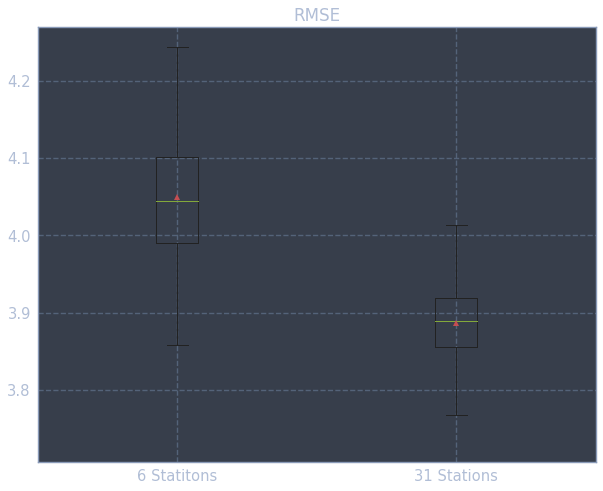

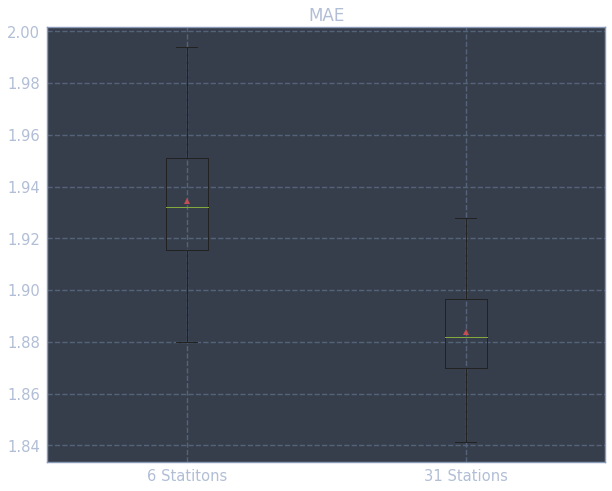

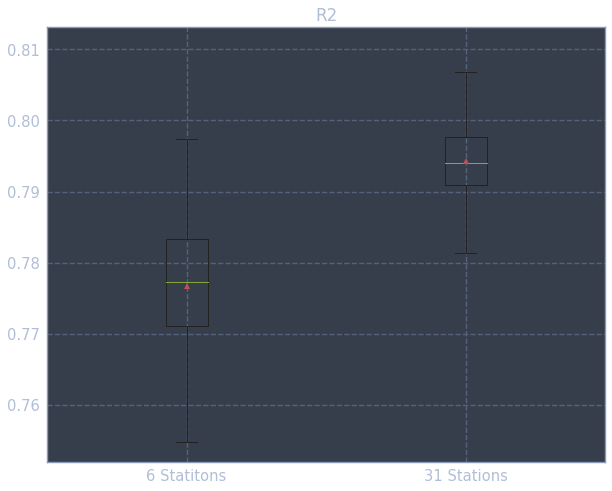

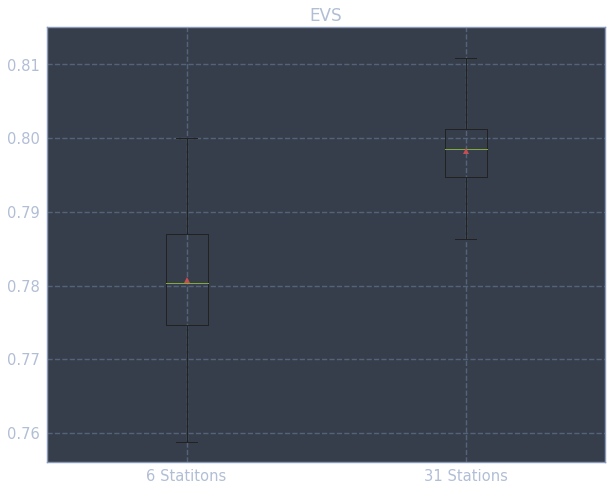

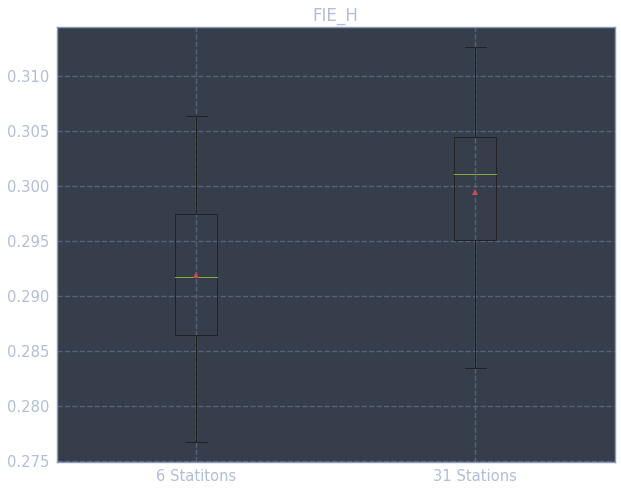

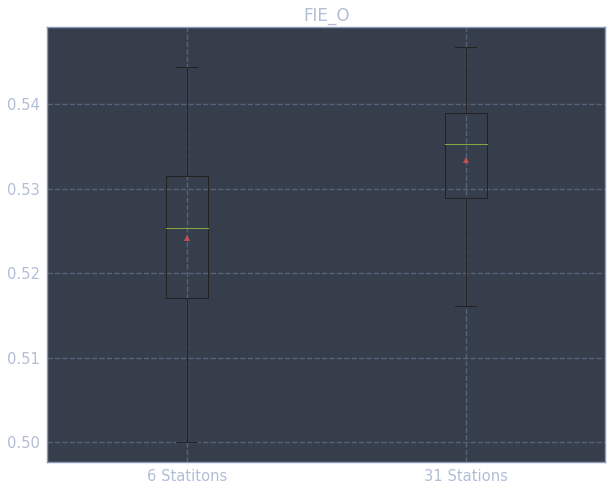

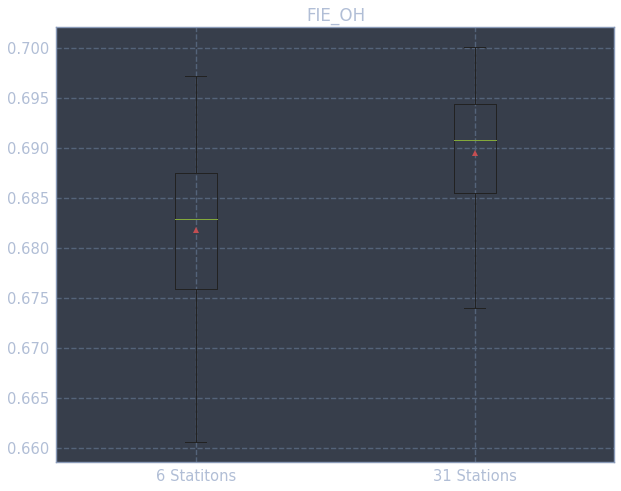

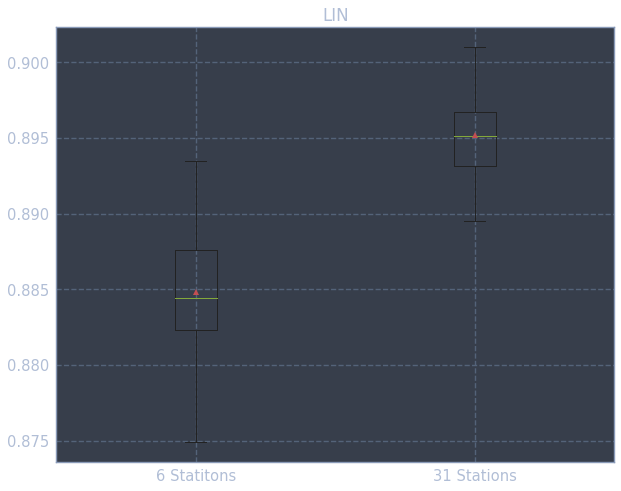

In [10]:
# I want a boxplot for each measure, showing test set comparison for 6station and 31station trained NNs
# plt.boxplot(x) makes a box for each column in x, so I need to feed 50x2 arrays to it

n = 0
for m in mess:
    plt.figure(n)
    exec(f'plt.boxplot({m}, labels=["6 Statitons", "31 Stations"], showmeans=True)')
    plt.title(m.upper())
    n += 1